## 🧬 HGS-CVRP

**Concepts:** [HGS-CVRP](../routers.md#hgs-cvrp) · [Meta-heuristics](../routers.md#meta-heuristics) **Network/Router API:** [🧬 HGSRouter](hi21_hgs.ipynb)

The meta-heuristic used is [HGS-CVRP](https://github.com/vidalt/HGS-CVRP) — see [HGS-CVRP](../routers.md#hgs-cvrp) for what it does and how its options behave.

[hgs_cvrp()](../autoapi/optiwindnet/baselines/hgs/index.rst#optiwindnet.baselines.hgs.hgs_cvrp) returns an electrical topology `S`. By default it solves an Open-CVRP, yielding a _radial_ topology; with `ringed=True` it solves a closed CVRP, producing a _ringed_ topology. Solutions can be used directly or as warm-starts for MILP models — see [Warm-starting](../routers.md#warm-starting).

If a routeset is desired, use _PathFinder_.

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.svg import svgplot
from optiwindnet.baselines.hgs import hgs_cvrp
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.interarraylib import G_from_S, as_normalized

### Load Hornsea

In [2]:
locations = load_repository()

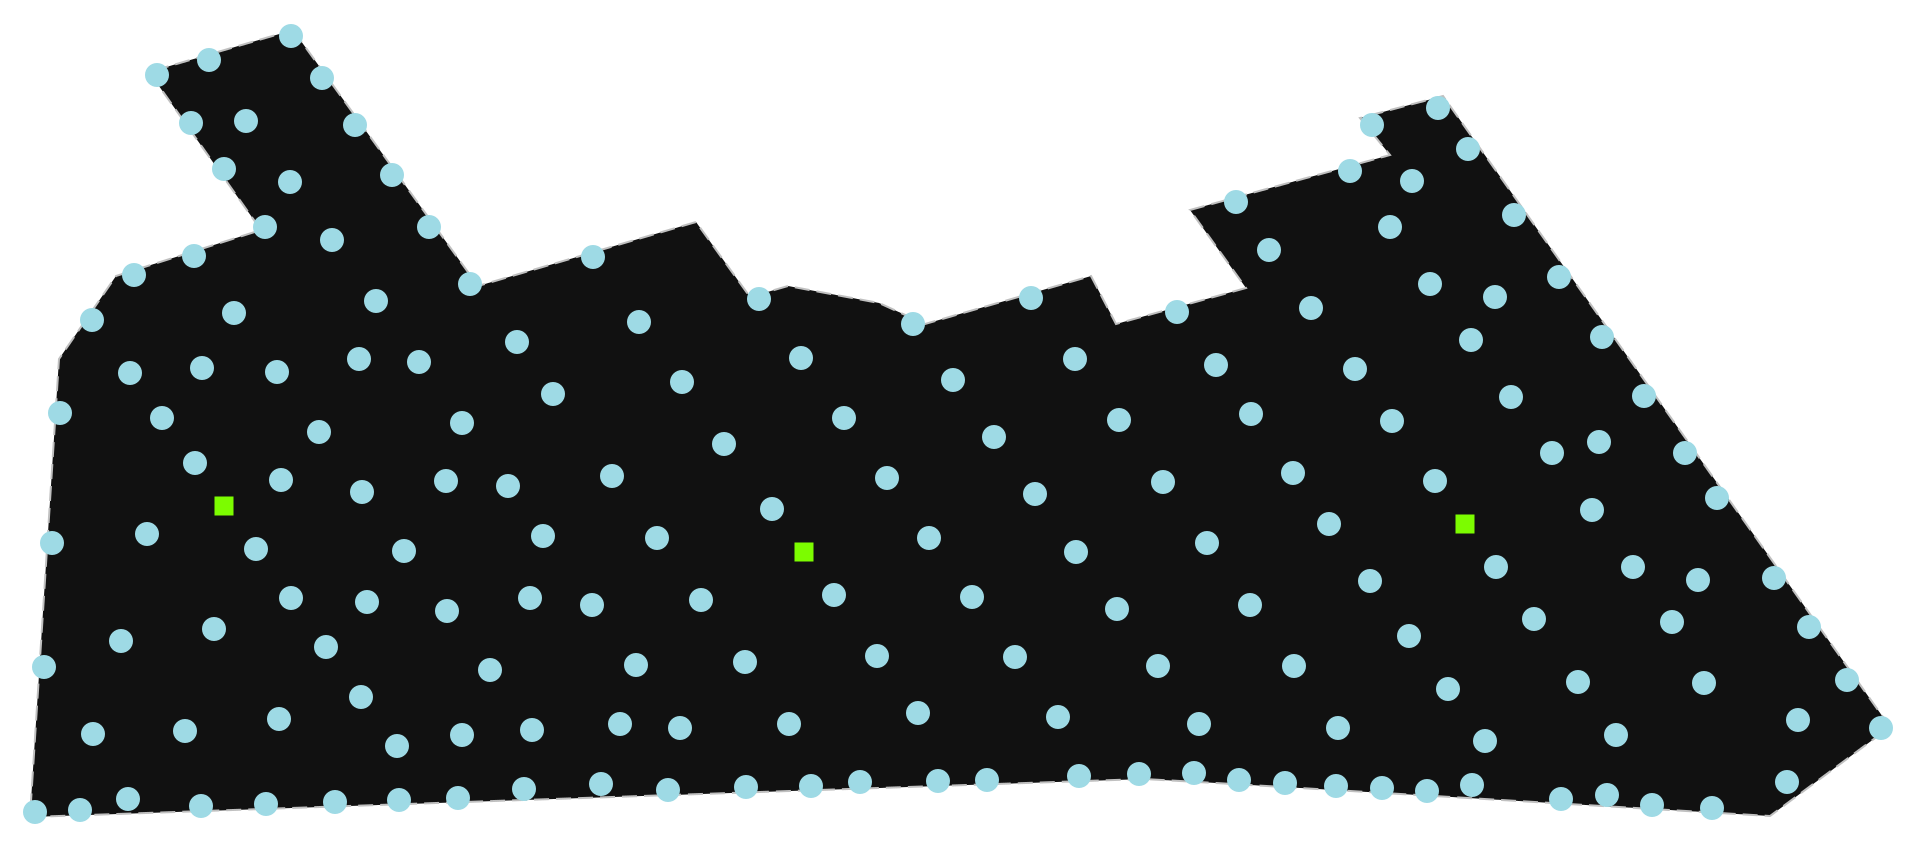

In [3]:
L = locations.hornsea
svgplot(L)

### Optimize Hornsea

(0.14, 0.1, 0.3)


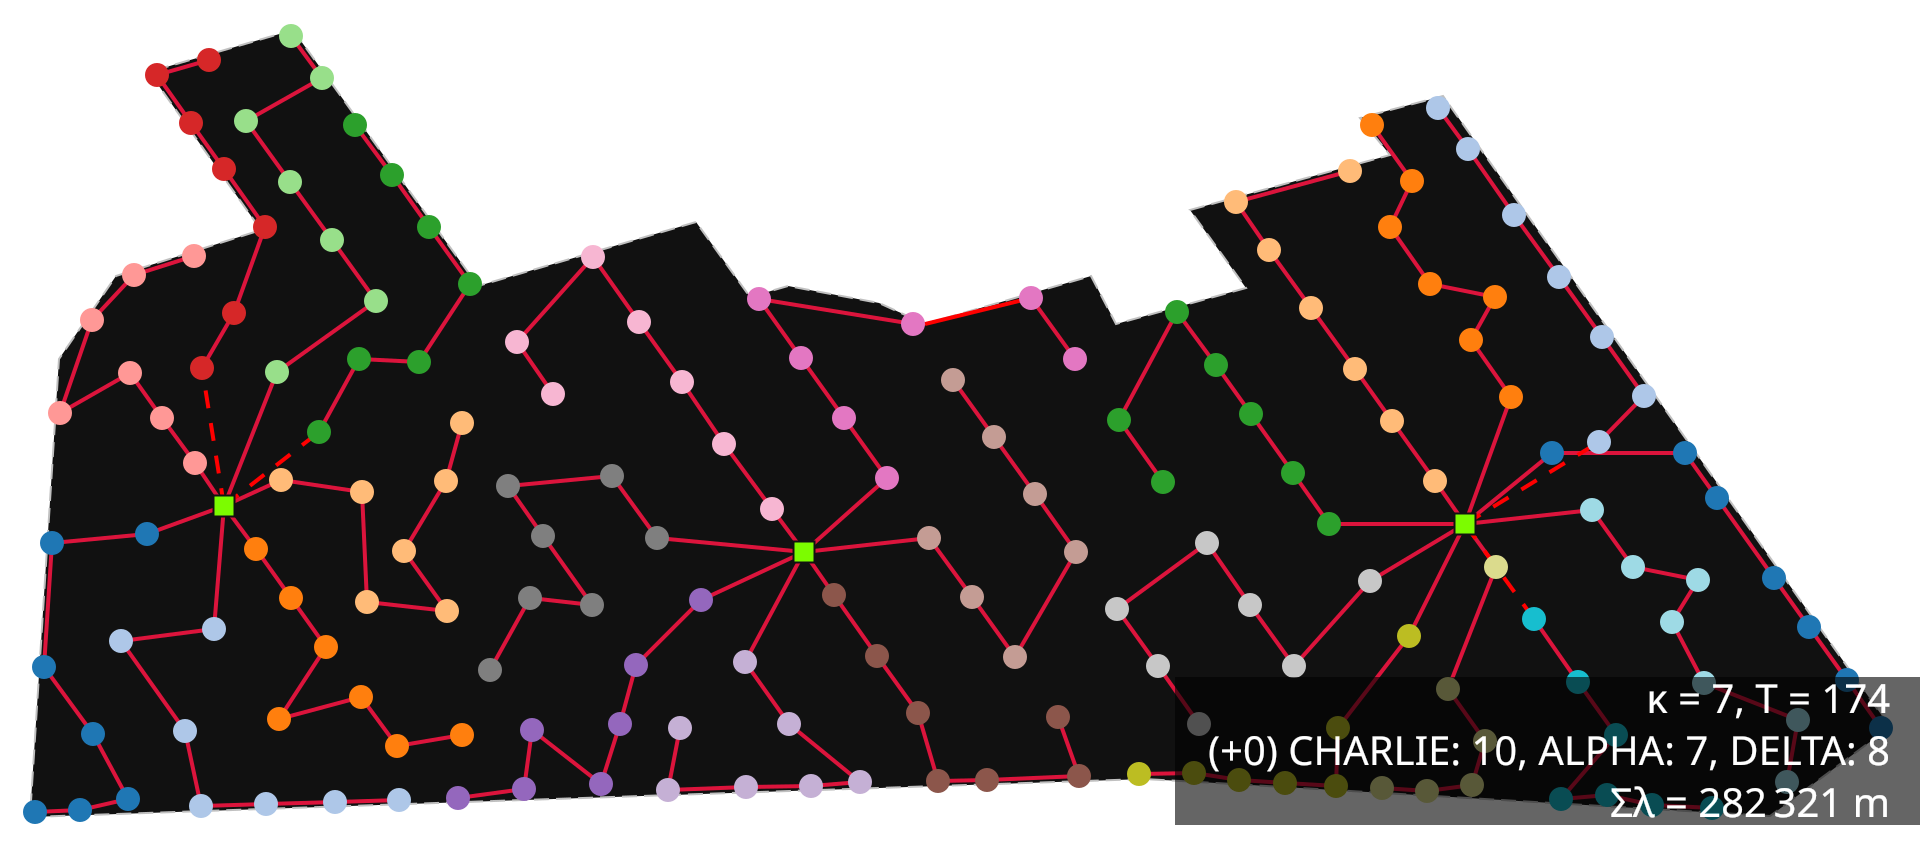

In [4]:
P, A = make_planar_embedding(L)
S = hgs_cvrp(as_normalized(A), capacity=7, time_limit=0.5)
print(S.graph['solution_time'])
G = G_from_S(S, A)
svgplot(G)

### Route the feeders so as to avoid crossings

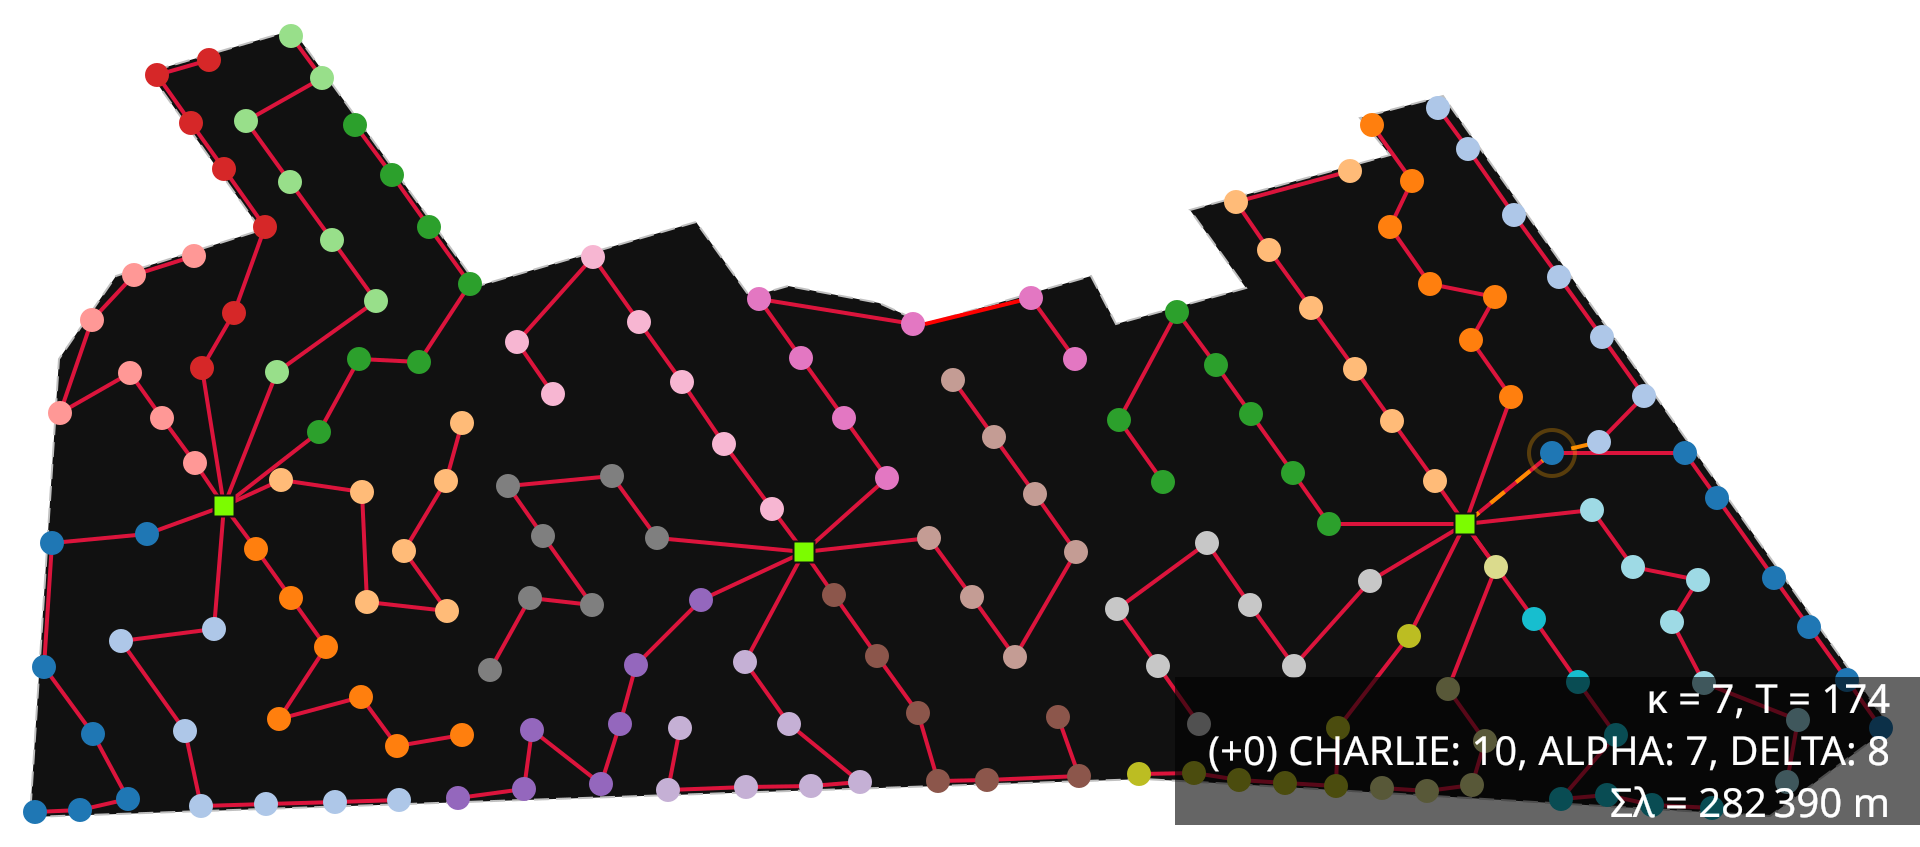

In [5]:
H = PathFinder(G, P, A).create_detours()
svgplot(H)

### Check the HGS-CVRP log

There are two alternatives to see the HGS log:

1. Store it in the solution object (must wait until HGS has finished)
2. Stream it using a callback function that gets one line per call

In [6]:
L = locations.meerwind
P, A = make_planar_embedding(L)

#### Store the log

In [7]:
S = hgs_cvrp(
    as_normalized(A),
    capacity=7,
    time_limit=0.5,
    keep_log=True,
)

In [8]:
print(S.graph['method_log'])

----- FLEET SIZE WAS NOT SPECIFIED: DEFAULT INITIALIZATION TO 18 VEHICLES
----- INSTANCE SUCCESSFULLY LOADED WITH 80 CLIENTS AND 18 VEHICLES
----- BUILDING INITIAL POPULATION
----- STARTING GENETIC ALGORITHM
It      0      2 | T(s) 0.04 | Feas 60 11.18 11.33 | NO-INFEASIBLE | Div 0.44 -1.00 | Feas 1.00 1.00 | Pen 5.81 0.85
It    500    234 | T(s) 0.17 | Feas 27 11.02 11.10 | NO-INFEASIBLE | Div 0.39 -1.00 | Feas 1.00 1.00 | Pen 2.58 0.38
It   1000    734 | T(s) 0.29 | Feas 35 11.02 11.08 | NO-INFEASIBLE | Div 0.35 -1.00 | Feas 1.00 1.00 | Pen 1.14 0.17
It   1500   1234 | T(s) 0.44 | Feas 43 11.02 11.10 | NO-INFEASIBLE | Div 0.37 -1.00 | Feas 1.00 1.00 | Pen 0.51 0.10
----- GENETIC ALGORITHM FINISHED AFTER 1714 ITERATIONS. TIME SPENT: 0.500016



#### Stream the log

In [9]:
S = hgs_cvrp(
    as_normalized(A),
    capacity=7,
    time_limit=0.5,
    log_callback=(lambda line: print(line, end='')),
)

----- FLEET SIZE WAS NOT SPECIFIED: DEFAULT INITIALIZATION TO 18 VEHICLES
----- INSTANCE SUCCESSFULLY LOADED WITH 80 CLIENTS AND 18 VEHICLES
----- BUILDING INITIAL POPULATION
----- STARTING GENETIC ALGORITHM
It      0      2 | T(s) 0.04 | Feas 60 11.15 11.36 | NO-INFEASIBLE | Div 0.45 -1.00 | Feas 1.00 1.00 | Pen 5.81 0.85
It    500    370 | T(s) 0.18 | Feas 27 11.02 11.14 | NO-INFEASIBLE | Div 0.41 -1.00 | Feas 1.00 1.00 | Pen 2.58 0.38
It   1000    870 | T(s) 0.33 | Feas 35 11.02 11.08 | NO-INFEASIBLE | Div 0.35 -1.00 | Feas 1.00 1.00 | Pen 1.14 0.17
It   1500   1370 | T(s) 0.49 | Feas 37 11.02 11.10 | Inf 12 11.53 11.67 | Div 0.35 0.33 | Feas 0.91 1.00 | Pen 0.51 0.10
----- GENETIC ALGORITHM FINISHED AFTER 1542 ITERATIONS. TIME SPENT: 0.500152


0.18


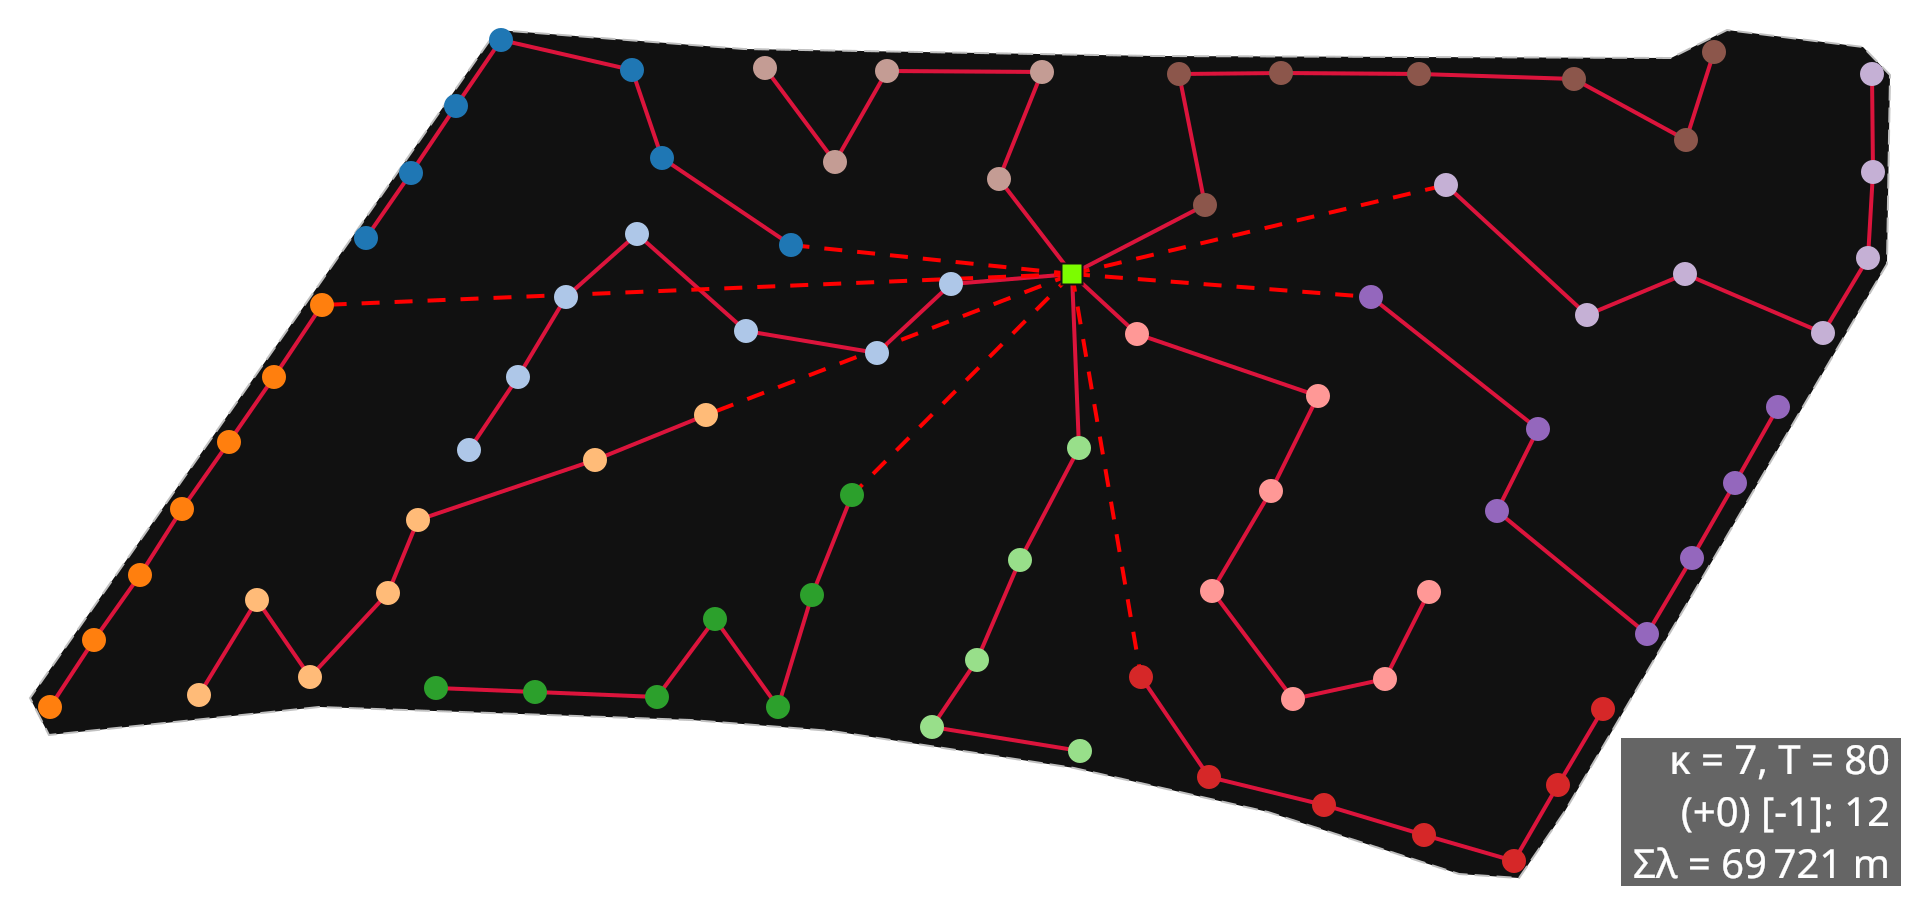

In [10]:
print(S.graph['solution_time'])
G = G_from_S(S, A)
svgplot(G)

### Optimize with Ringed Topology

With `ringed=True`, HGS-CVRP connects subtrees into closed loops (rings) attached to the substation at both ends.

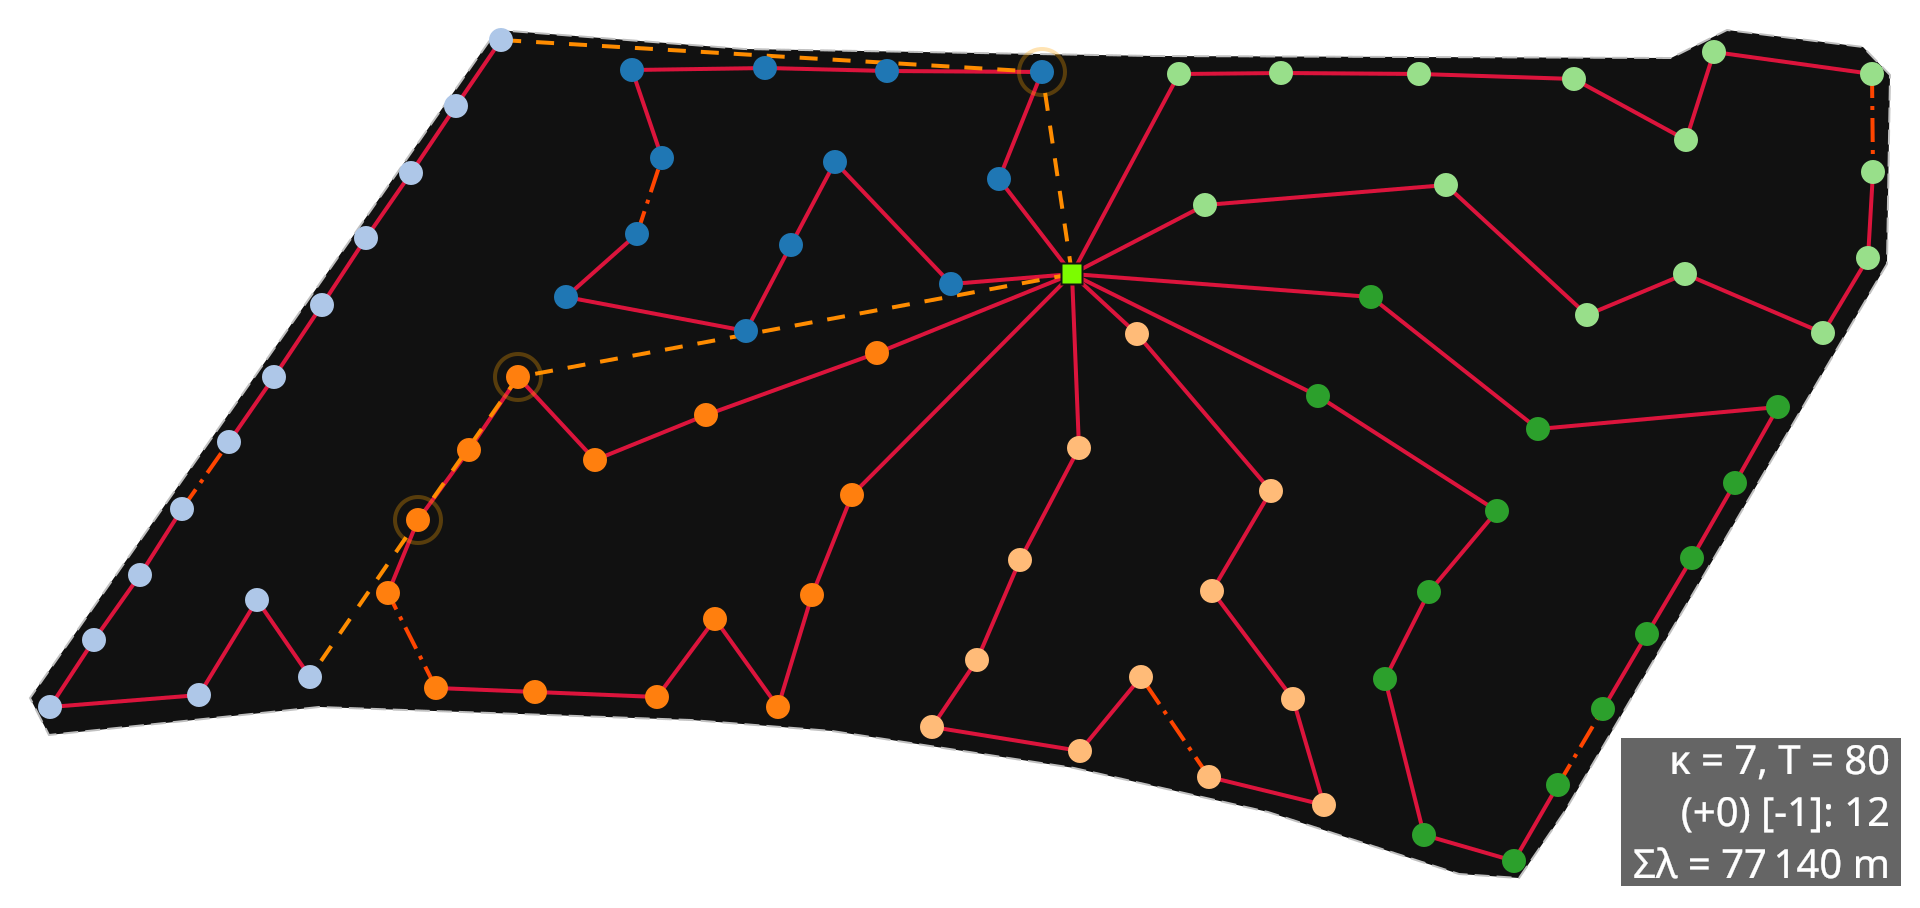

In [11]:
S_ring = hgs_cvrp(as_normalized(A), capacity=7, time_limit=0.5, ringed=True)
G_ring = G_from_S(S_ring, A)
H_ring = PathFinder(G_ring, P, A).create_detours()
svgplot(H_ring)

### Current HGS options

[hgs_cvrp()](../autoapi/optiwindnet/baselines/hgs/index.rst#optiwindnet.baselines.hgs.hgs_cvrp) supports multiple substations: it clusters terminals by root and solves each cluster. Use `seed` for reproducible runs. By default `repair=True` iteratively repairs crossings; `max_retries` bounds that work, so total runtime can reach `(max_retries + 1) * time_limit`.

`vehicles` is normally an upper bound on feeder count. Set `balanced=True` to balance feeder loads. `vehicles_exact=True` fixes the count, but requires `balanced=True` and is limited to a single-root, non-ringed problem. HGS produces an electrical topology; use [G_from_S()](../autoapi/optiwindnet/interarraylib/index.rst#optiwindnet.interarraylib.G_from_S) and then [PathFinder](../autoapi/optiwindnet/pathfinding/index.rst#optiwindnet.pathfinding.PathFinder) to obtain physical routes.